# Stimulating the brain

Driving a neural-mass model with an Event

Marius Pille (Berlin Institute of Health at Charité University
Medicine)  
Leon Martin (Berlin Institute of Health at Charité University
Medicine)  
Leon Stefanovski (Charité University Medicine Berlin)

## Goal

Use a TVB-O `SimulationExperiment` with a stimulus defined as an
`Event`. Compare the resting and stimulated time series.

In [1]:
from tvbo import Dynamics, SimulationExperiment
from tvbo.datamodel.schema import Event

## 1. A baseline experiment

Start with the `Generic2dOscillator` (G2D) and its database defaults.
The trajectory relaxes onto a stable focus at `V ≈ −0.19`. These
parameters are **far from any oscillation**.


STEP 1: Running simulation...
  Simulation period: 1000.0 ms, dt: 0.01220703125 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.

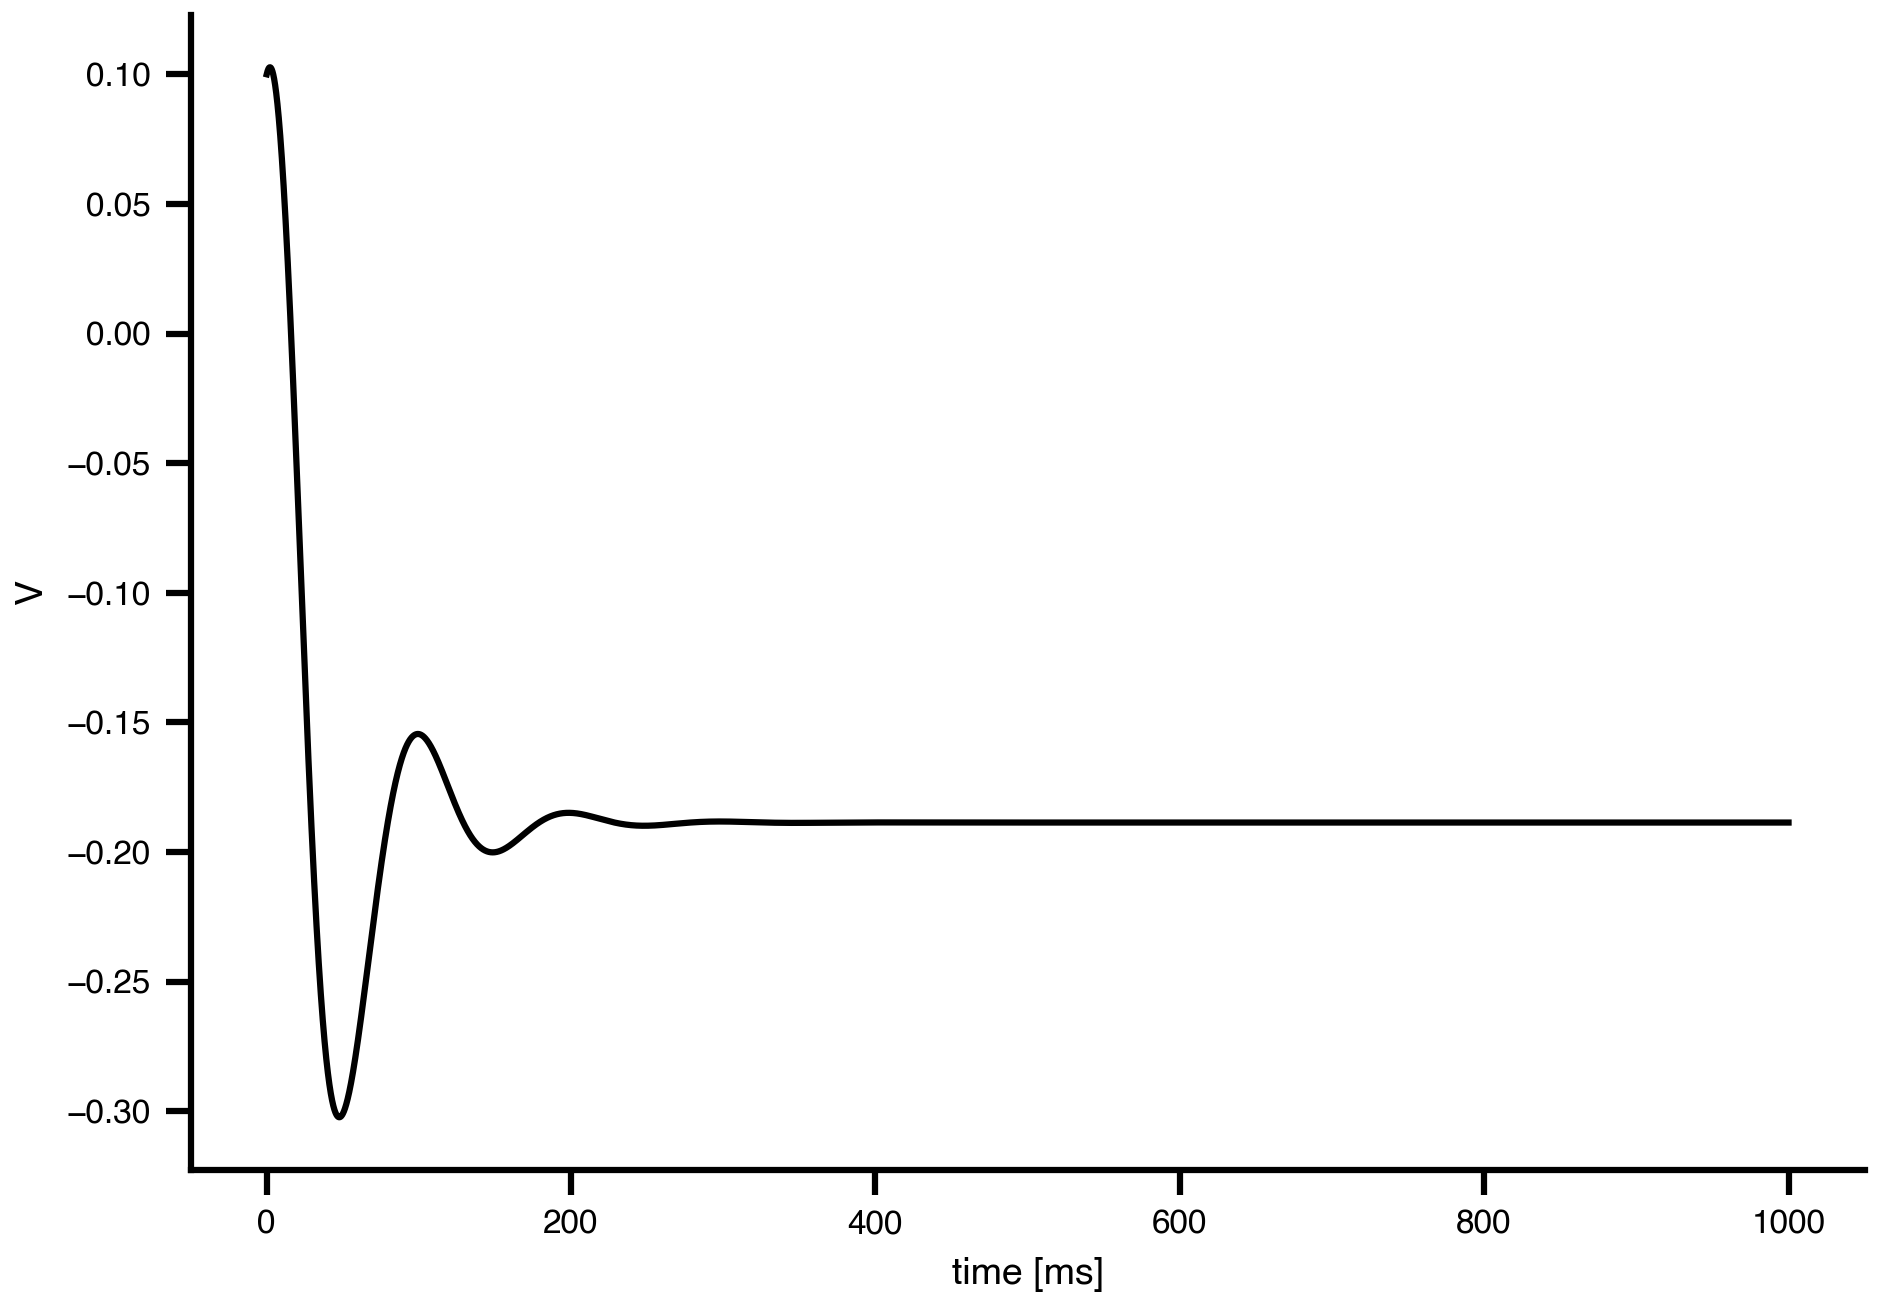

In [2]:
g2d = Dynamics.from_db("Generic2dOscillator")

exp = SimulationExperiment(dynamics=g2d)
res = exp.run()
res.integration.sel(variable="V").plot()

## 2. Define a stimulus as an `Event`

An `Event` is a symbolic, time-dependent perturbation. Here, a
rectangular pulse is defined using `Piecewise`. Any expression in `t`
and the event’s parameters is valid.

In [3]:
event = Event(
    name="perturbation",
    event_type="stimulus",
    parameters={
        "onset":     {"value": 200.0},
        "width":     {"value": 200.0},
        "amplitude": {"value": 1.0},
    },
    equation={
        "rhs": "Piecewise((amplitude, (t >= onset) & (t < onset + width)), (0.0, True))"
    },
)
event.plot();

> **Note**
>
> The default G2D enters the oscillatory regime at `I ≈ 3.7` (lower
> Hopf). At `I + perturbation = 5`, the system is **above** the Hopf, so
> a limit cycle appears during the pulse.

## 3. Inject the event into the model

Steps: 1. Register the event under `exp.events["<name>"]`. 2. Edit the
right-hand side of the state variable to be driven. Here, for `V`,
replace the constant input `I` with `(I + perturbation)`.

In [4]:
exp.events["perturbation"] = event
exp.dynamics.state_variables["V"].equation.rhs = (
    "d*tau*((I + perturbation)*gamma - V**3*f + V**2*e + V*g "
    "+ V*local_coupling + W*alpha + c_glob*gamma)"
)

> **Widen the `W` domain before running**
>
> G2D uses `W ∈ [−6, 6]` as its state-variable domain. The JAX kernel
> wraps `Heun` in a `BoundedSolver` that clamps `W` at those limits. At
> `I = 5`, the limit cycle swings `W` down to about `−9`, so the solver
> pins `W` at `−6`. `V` then settles on the cubic’s right branch at
> `V ≈ 2.88`, a square plateau rather than an oscillation. Widen the
> domain before running.


STEP 1: Running simulation...
  Simulation period: 1000.0 ms, dt: 0.01220703125 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.

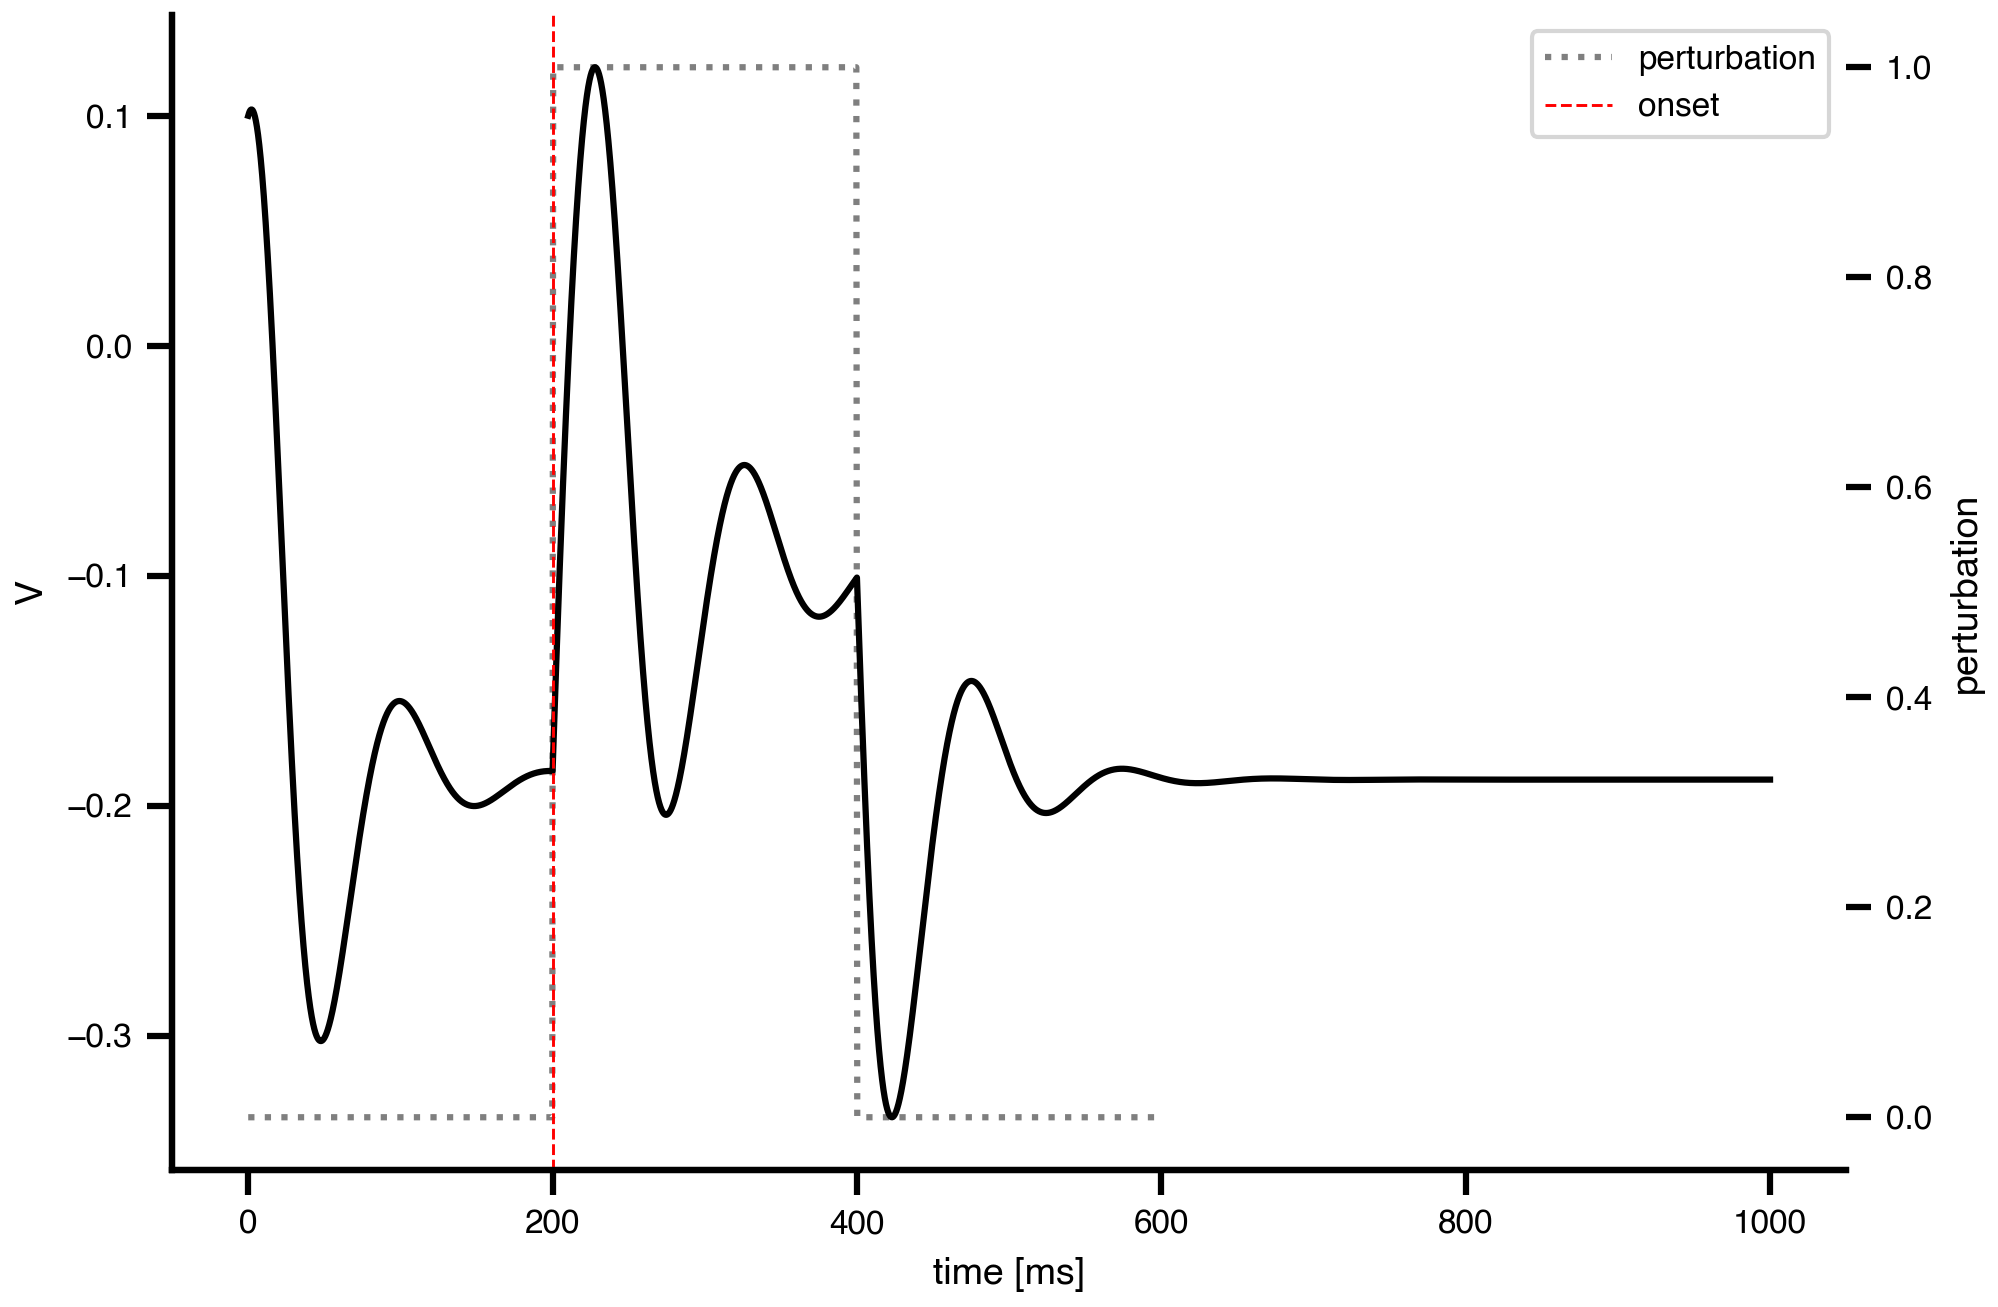

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
exp.dynamics.state_variables["W"].domain.lo = -20.0
exp.dynamics.state_variables["W"].domain.hi = 20.0

res_stim = exp.run()
res_stim.integration.sel(variable="V").plot(ax=ax)
ax2=ax.twinx()
event.plot(ax=ax2, alpha=0.5, linestyle=':')

Now the trajectory oscillates during the pulse and returns to the stable
focus after.

## 4. Five-node motif: stimulus propagation

The five-region motif below uses the same parameter regime as the
Bayesian workshop example. The stimulus is brief, so R0 gives one evoked
response rather than a long driven oscillation. Edge weights and tract
lengths live in edge parameters.

        R0 -> R1 -> R2
              |
              v
              R3 -> R4

R0 is the stimulated site (peripheral). R1 is a hub (degree 3) with high
excitability. R3 is also hyperexcitable. R2 and R4 are quiet leaves.

> **Coupling gain**
>
> Use `a = 0.1`, matching the workshop example. The node excitabilities
> are `I = [0.05, 0.30, 0.05, 0.25, 0.05]`: R1 and R3 are hot, R0, R2,
> and R4 are quiet.

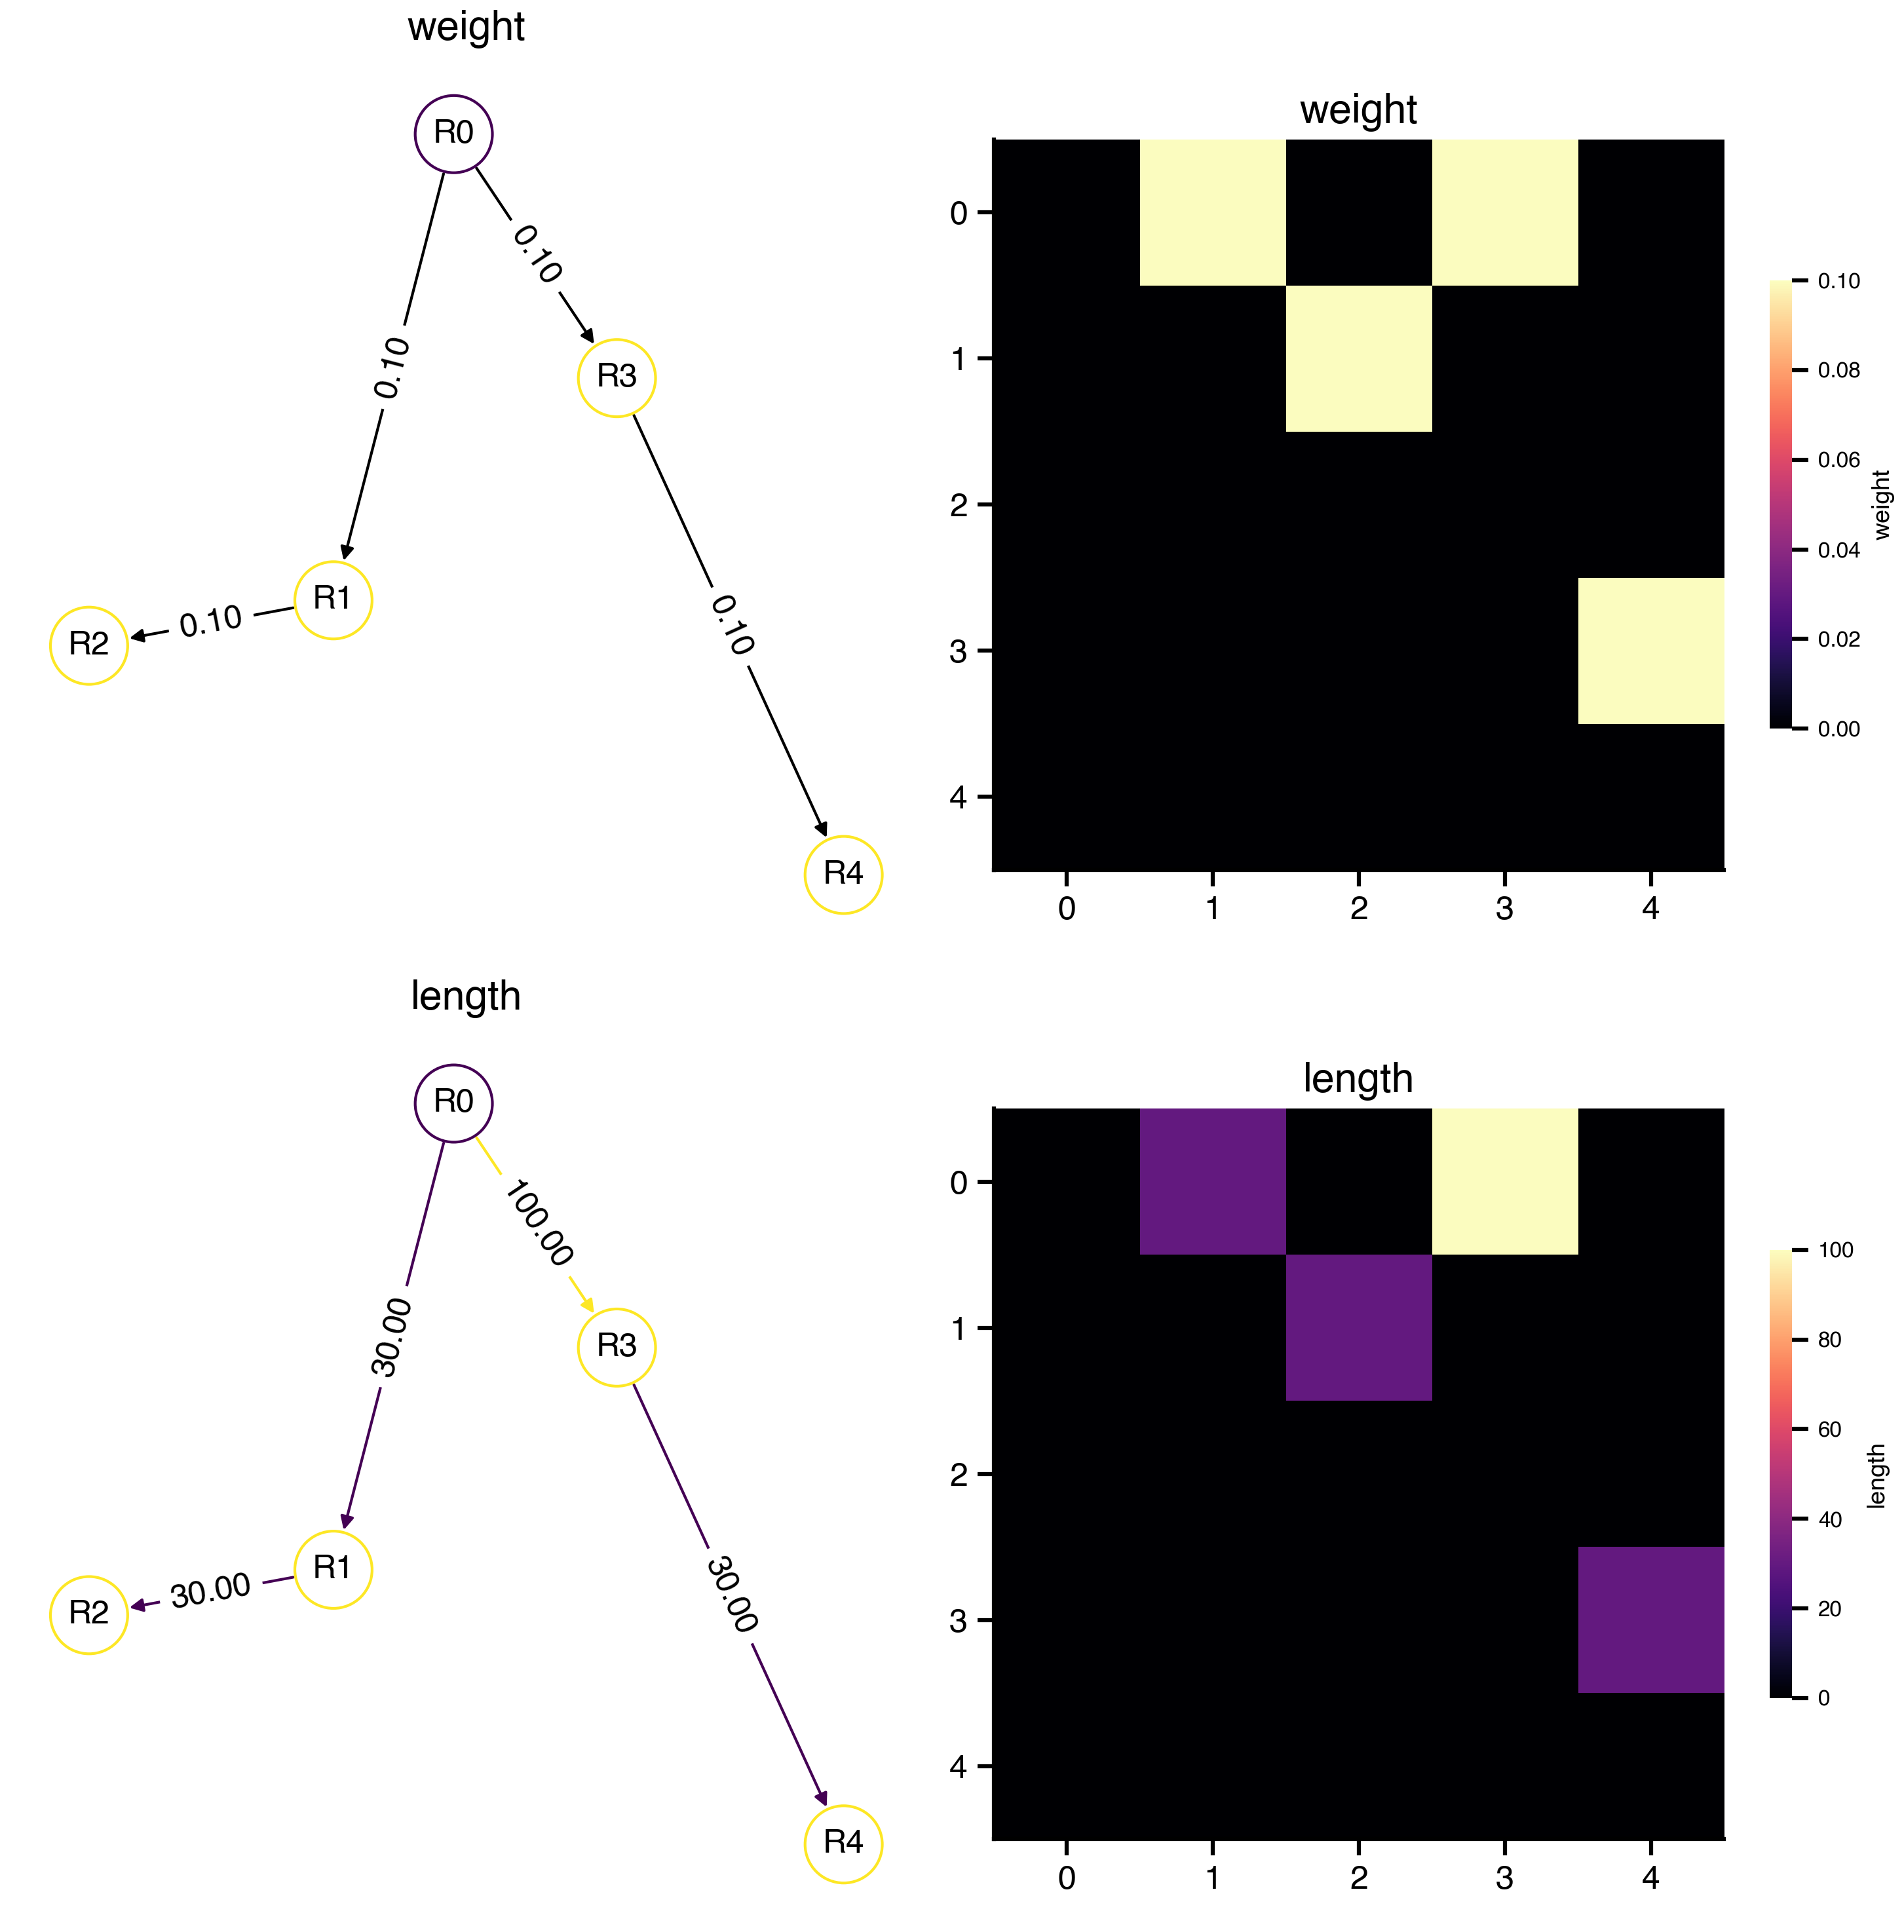

In [6]:
from tvbo import Network, SimulationExperiment, Dynamics, Coupling
from tvbo.datamodel.schema import Event

T1 = 150.0
DT = 0.2
ONSET = 10.0
DURATION = 1.0
G_COUPLING = 0.1
TRUE_AMPLITUDE = 0.4
DYNAMICS_PARAMS = {
    "a": -1.5,
    "b": -15.0,
    "c": 0.0,
    "d": 0.015,
    "e": 3.0,
    "f": 1.0,
    "tau": 4.0,
}

network_yaml = """
label: StimPropagationMotif
number_of_nodes: 5
nodes:
    - {id: 0, label: R0, description: "stimulated site, peripheral, quiet", parameters: {I: {value: 0.05}}}
    - {id: 1, label: R1, description: "hub, hyperexcitable", parameters: {I: {value: 0.30}}}
    - {id: 2, label: R2, description: "quiet leaf", parameters: {I: {value: 0.05}}}
    - {id: 3, label: R3, description: "hyperexcitable branch node", parameters: {I: {value: 0.25}}}
    - {id: 4, label: R4, description: "quiet leaf", parameters: {I: {value: 0.05}}}
edges:
    - {source: 0, target: 1, directed: true, parameters: {weight: {value: .1}, length: {value: 30.0, unit: mm}}}
    - {source: 0, target: 3, directed: true, parameters: {weight: {value: .1}, length: {value: 100.0, unit: mm}}}
    - {source: 3, target: 4, directed: true, parameters: {weight: {value: .1}, length: {value: 30.0, unit: mm}}}
    - {source: 1, target: 2, directed: true, parameters: {weight: {value: .1}, length: {value: 30.0, unit: mm}}}
"""

network = Network.from_string(network_yaml)

network.plot_overview()

In [7]:
event = Event(
    name="perturbation",
    event_type="stimulus",
    parameters={
        "onset": {"value": ONSET},
        "duration": {"value": DURATION},
        "amplitude": {"value": TRUE_AMPLITUDE},
    },
    equation={"rhs": "Piecewise((amplitude, (t >= onset) & (t < onset + duration)), (0.0, True))"},
    regions=[0],
    weighting=[1.0],
)

dynamics = Dynamics.from_db("Generic2dOscillator")
for name, value in DYNAMICS_PARAMS.items():
    dynamics.parameters[name].value = value

exp = SimulationExperiment(
    dynamics=dynamics,
    coupling=Coupling(name="Linear", parameters={"a": {"value": G_COUPLING}, "b": {"value": 0.0}}),
    network=network,
)
exp.events["perturbation"] = event

exp.dynamics.state_variables["V"].equation.rhs = (
    "d*tau*((I + perturbation)*gamma - V**3*f + V**2*e + V*g "
    "+ V*local_coupling + W*alpha + c_glob*gamma)"
)
exp.integration.duration = T1
exp.integration.step_size = DT

res = exp.run()


STEP 1: Running simulation...
  Simulation period: 150.0 ms, dt: 0.2 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.

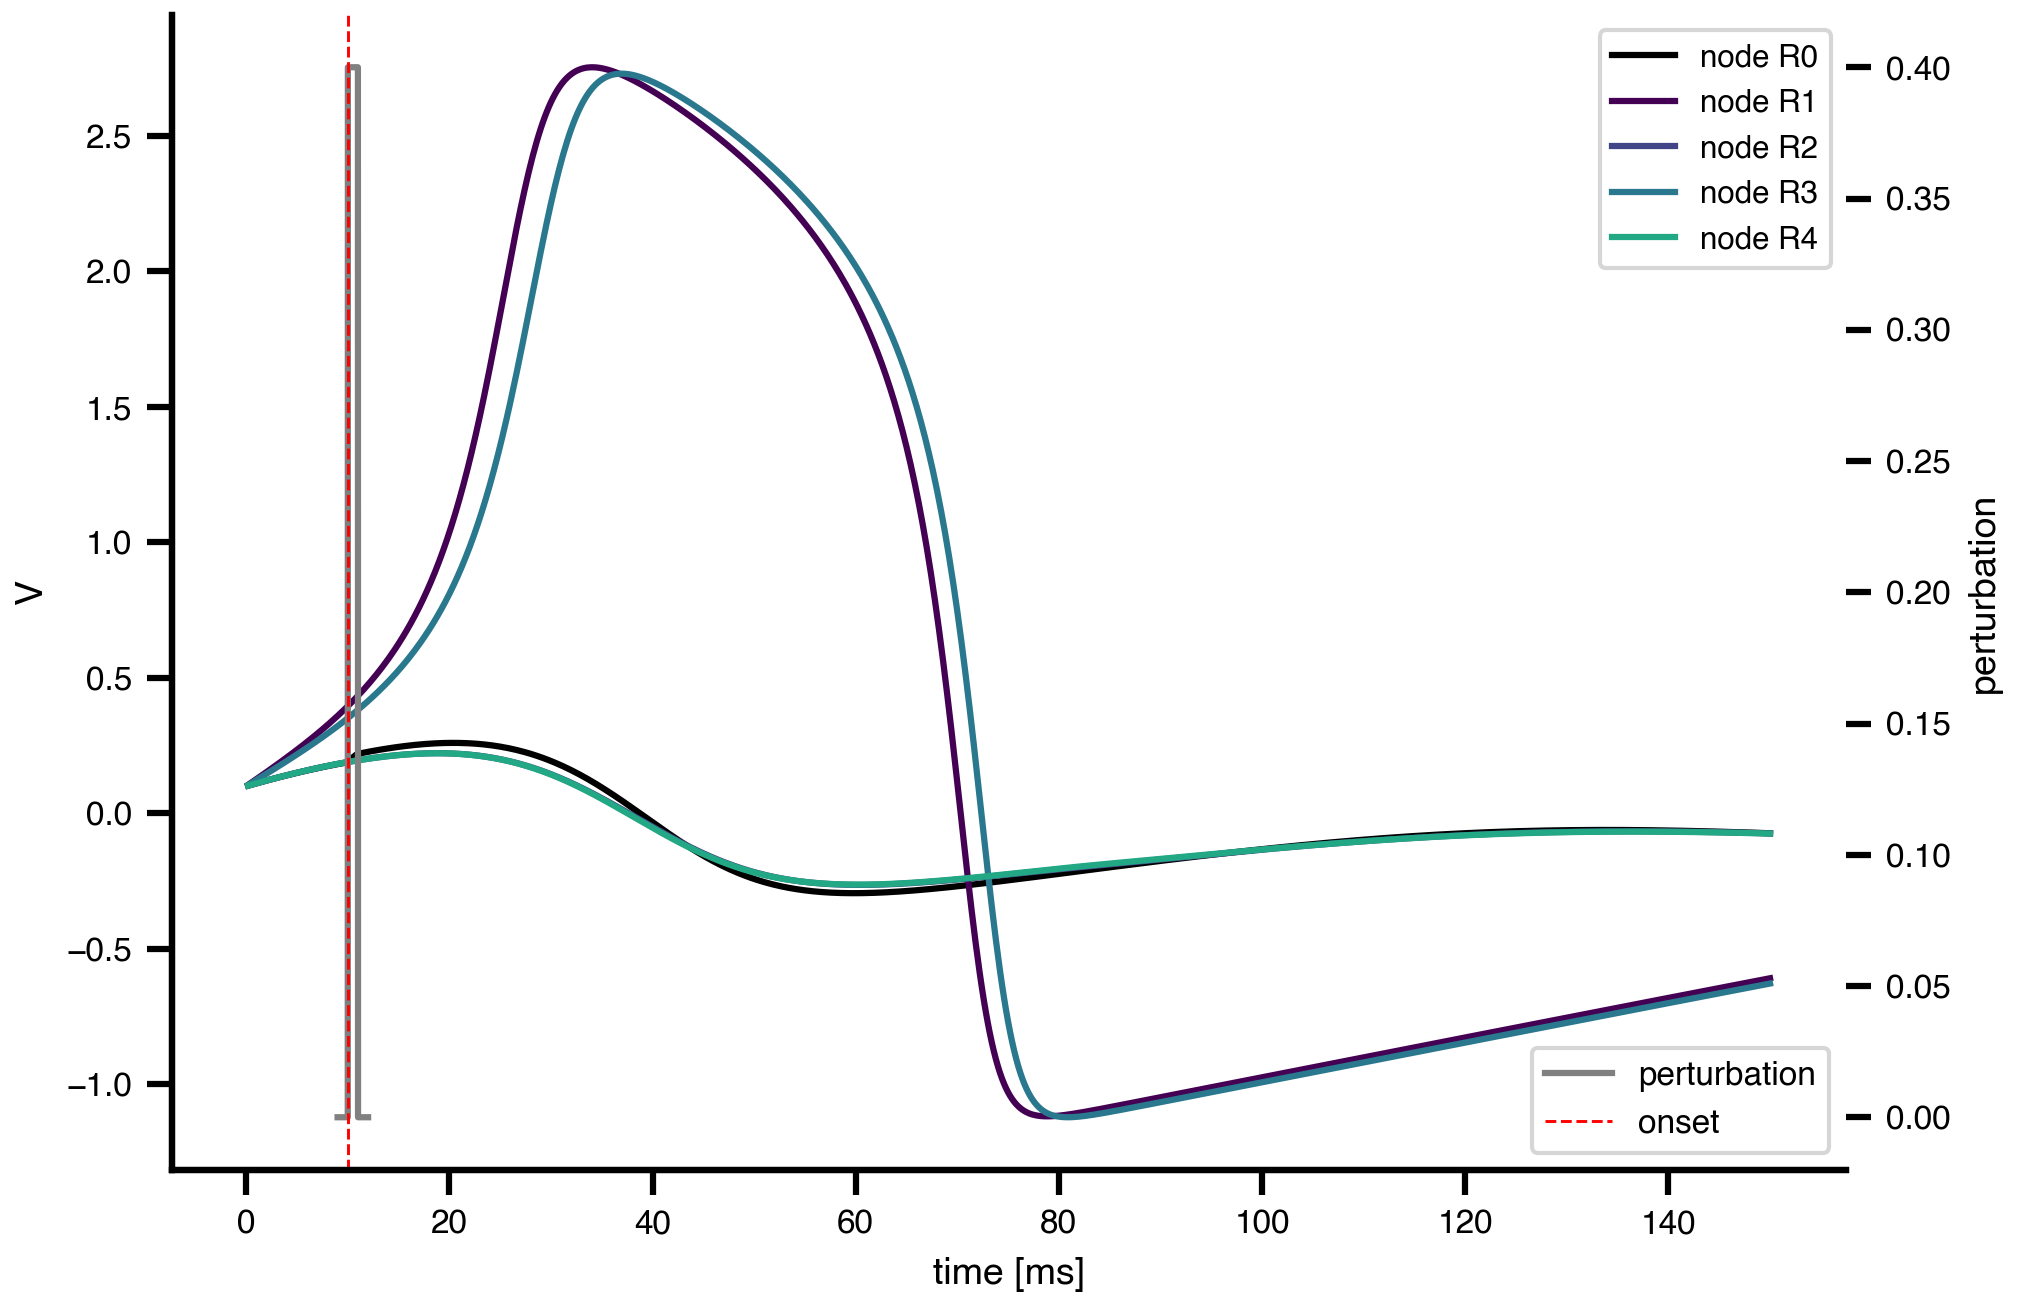

In [8]:
fig, ax = plt.subplots()
res.integration.sel(variable="V").plot(ax=ax)
ax2 = ax.twinx()
event.plot(ax=ax2, color="grey")
leg = ax2.get_legend()
leg.set_loc('lower right')

Run the same experiment again with a slower transmission speed. The edge
lengths are unchanged; only `conduction_speed` changes, so delays scale
as `length / conduction_speed`.


STEP 1: Running simulation...
  Simulation period: 150.0 ms, dt: 0.2 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.
conduction_speed = 1 mm/ms
[[  0.   0.   0.   0.   0.]
 [ 30.   0.   0.   0.   0.]
 [  0.  30.   0.   0.   0.]
 [100.   0.   0.   0.   0.]
 [  0.   0.   0.  30.   0.]]

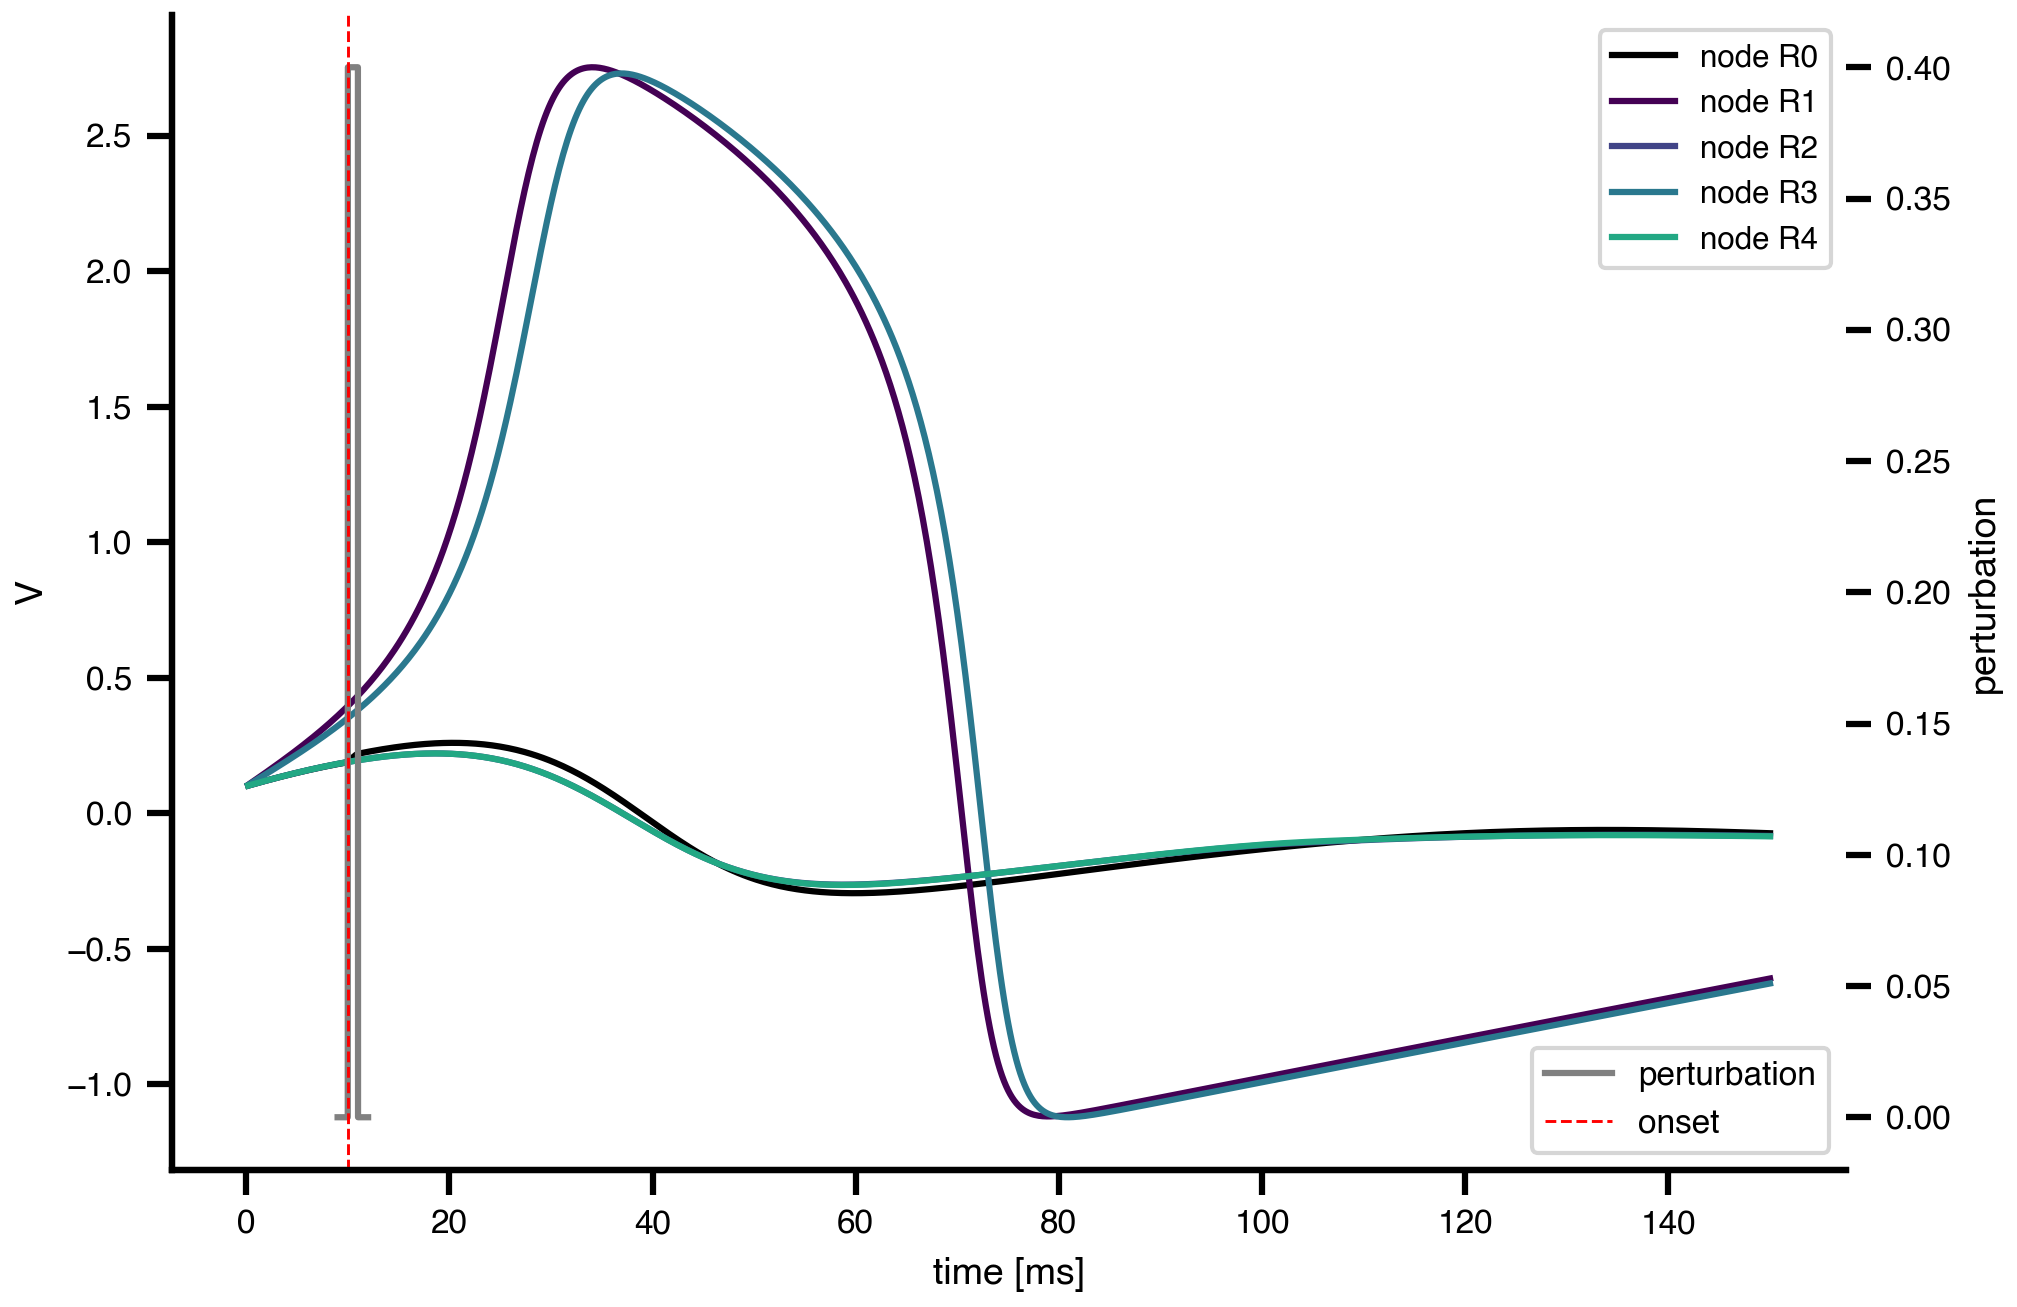

In [9]:
SLOW_CONDUCTION_SPEED = 1

slow_network = Network.from_string(network_yaml)
slow_network.parameters["conduction_speed"].value = SLOW_CONDUCTION_SPEED

slow_dynamics = Dynamics.from_db("Generic2dOscillator")
for name, value in DYNAMICS_PARAMS.items():
    slow_dynamics.parameters[name].value = value

slow_exp = SimulationExperiment(
    dynamics=slow_dynamics,
    coupling=Coupling(name="Linear", parameters={"a": {"value": G_COUPLING}, "b": {"value": 0.0}}),
    network=slow_network,
)
slow_exp.events["perturbation"] = event
slow_exp.dynamics.state_variables["V"].equation.rhs = exp.dynamics.state_variables["V"].equation.rhs
slow_exp.integration.duration = T1
slow_exp.integration.step_size = DT

slow_res = slow_exp.run()

print(f"conduction_speed = {SLOW_CONDUCTION_SPEED} mm/ms")
print(slow_network.calculate_delays())

fig, ax = plt.subplots()
slow_res.integration.sel(variable="V").plot(ax=ax)
ax2 = ax.twinx()
event.plot(ax=ax2, color="grey")
leg = ax2.get_legend()
leg.set_loc("lower right")

**Result:** The current pulse starts at 10 ms and lasts 1 ms. R0’s
voltage peak appears later because the state variable needs time to move
after the input turns on. Downstream peaks shift by
`length / conduction_speed`: the 30 mm and 100 mm branches separate most
clearly. The edges are directed, so the response does not travel back
into earlier nodes.

## Exercises

1.  **Iso-energy comparison.** Keep the *energy* `amplitude × width`
    constant but shrink `width` (e.g. `width=20, amplitude=50` instead
    of `width=200, amplitude=5`). Plot the response. Is a brief, strong
    kick more or less efficient at triggering the limit cycle than a
    long, gentle one? Consider the system’s relaxation time vs. the
    pulse duration.
2.  **Phase / timing effects.** Once the system is on the limit cycle,
    the response to a second pulse depends on **when** it arrives within
    the cycle. Re-run with two events (`exp.events["pulse1"]`,
    `exp.events["pulse2"]`) at the same amplitude but different `onset`
    values offset by a fraction of the cycle period. Compare the
    trajectories and look for constructive or destructive interference.
3.  **Sub-threshold pulse.** Reduce `amplitude` to `0.1` and re-run. You
    should see only a small damped twitch around the pulse, because the
    system never leaves the basin of the stable fixed point.
4.  **Closer to the bifurcation.** Set the baseline `I`
    (`exp.dynamics.parameters["I"].value = 2.9`) and re-run with a small
    `amplitude`. A tiny perturbation now triggers oscillations.
5.  **Different waveform.** Replace the `Piecewise` rhs with a Gaussian,
    `amplitude*exp(-((t-onset)/width)**2)`, and observe the smoother
    response.
6.  **Different target.** Inject the event into `W` instead of `V` by
    editing `exp.dynamics.state_variables["W"].equation.rhs`.